# Упражнения <a id='tasks'></a>

Необходимо изучить библиотеку [tslearn](https://tslearn.readthedocs.io/en/stable/).

1. Взять выбранные для лабы 14 набор(ы) данных. 

3. Попробовать все методы классификации и регрессии, описанные в блоноте 14 aeon:
    Distance-based 
    Свертки (модели семейства Rocket и Hydra)
    Feature-based
    Deep Learning

    Для каждого подхода обучть не менее 3х разных моделей для классификации и регрессии.
    
     
    

In [11]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier, KNeighborsTimeSeriesRegressor
from tslearn.svm import TimeSeriesSVC, TimeSeriesSVR
from tslearn.clustering import TimeSeriesKMeans, KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler
from tslearn.metrics import dtw, cdist_dtw, soft_dtw
from tslearn.utils import to_time_series_dataset
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from aeon.datasets import load_classification


X_train_raw, y_train_raw = load_classification("Beef", split="train")
X_test_raw, y_test_raw = load_classification("Beef", split="test")

X_train = np.moveaxis(X_train_raw, 1, -1)
X_test = np.moveaxis(X_test_raw, 1, -1)

In [3]:
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

print(X_train.shape)
print(X_test.shape)
print(le.classes_)

(30, 470, 1)
(30, 470, 1)
['1' '2' '3' '4' '5']


In [7]:
def plot_tslearn(X, y):
    plt.figure(figsize=(12, 5))
    classes = np.unique(y)
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    
    for idx, cls in enumerate(classes):
        indices = np.where(y == cls)[0][:3]
        
        for i, global_idx in enumerate(indices):
            add_label = (i == 0)
            
            plt.plot(
                X[global_idx, :, 0], 
                color=colors[idx], 
                alpha=0.6,
                label=f"Class {cls}" if add_label else ""  
            )
    
    plt.title("Dataset")
    plt.xlabel("Time step")
    plt.ylabel("Spectral value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

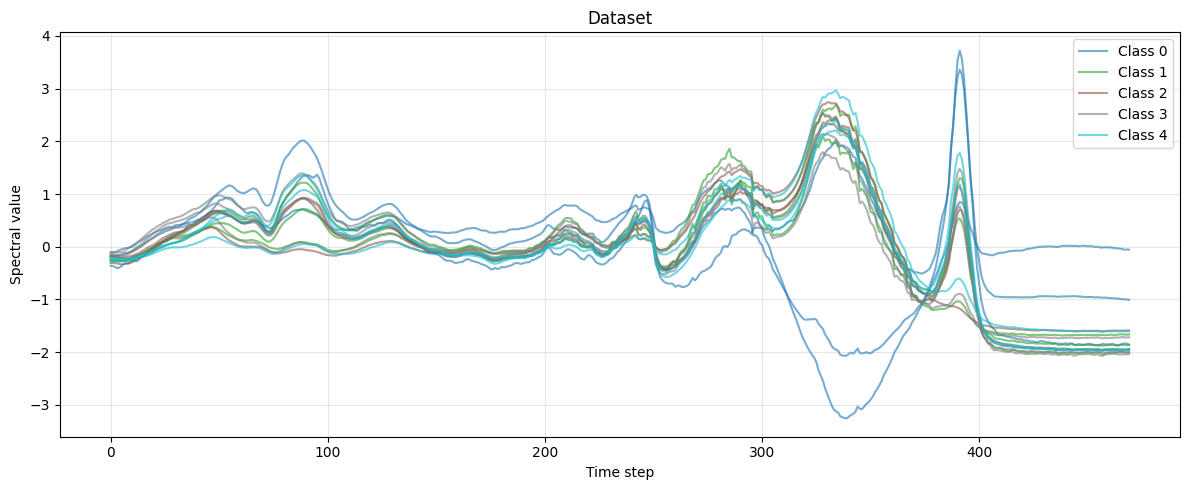

In [8]:
plot_tslearn(X_train, y_train)

In [9]:
results = {"Model": [], "Accuracy": [], "Type": []}

In [10]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.barycenters import dtw_barycenter_averaging


for k in [1, 3, 5]:
    clf = KNeighborsTimeSeriesClassifier(
        n_neighbors=k,
        metric="dtw",
        metric_params={"sakoe_chiba_radius": 10}
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results["Model"].append(f"kNN-DTW (k={k})")
    results["Accuracy"].append(acc)
    results["Type"].append("Distance-based")
    print(f"kNN-DTW (k={k})   Accuracy: {acc:.3f}")



clf_softdtw = KNeighborsTimeSeriesClassifier(
    n_neighbors=3,
    metric="softdtw",
    metric_params={"gamma": 0.1}
)
clf_softdtw.fit(X_train, y_train)
y_pred = clf_softdtw.predict(X_test)
acc = accuracy_score(y_test, y_pred)

results["Model"].append("kNN-SoftDTW")
results["Accuracy"].append(acc)
results["Type"].append("Distance-based")
print(f"kNN-SoftDTW   Accuracy: {acc:.3f}")



clf_euc = KNeighborsTimeSeriesClassifier(
    n_neighbors=3,
    metric="euclidean"
)
clf_euc.fit(X_train, y_train)
y_pred = clf_euc.predict(X_test)
acc = accuracy_score(y_test, y_pred)

results["Model"].append("kNN-Euclidean")
results["Accuracy"].append(acc)
results["Type"].append("Distance-based")
print(f"kNN-Euclidean   Accuracy: {acc:.3f}")

kNN-DTW (k=1)   Accuracy: 0.733
kNN-DTW (k=3)   Accuracy: 0.600
kNN-DTW (k=5)   Accuracy: 0.400
kNN-SoftDTW   Accuracy: 0.567
kNN-Euclidean   Accuracy: 0.600


In [13]:
def extract_features(X):
    features = []
    for series in X:
        s = series[:, 0]
        feats = [
            np.mean(s), np.std(s), np.min(s), np.max(s),
            np.percentile(s, 25), np.percentile(s, 75),
            np.mean(np.diff(s)),
            np.std(np.diff(s))
        ]
        features.append(feats)
    return np.array(features)

In [14]:
X_train_feat = extract_features(X_train)
X_test_feat = extract_features(X_test)

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_feat, y_train)
y_pred = rf.predict(X_test_feat)
acc = accuracy_score(y_test, y_pred)

results["Model"].append("RandomForest")
results["Accuracy"].append(acc)
results["Type"].append("Feature-based")
print(f"RandomForest   Accuracy: {acc:.3f}")



svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_feat, y_train)
y_pred = svm.predict(X_test_feat)
acc = accuracy_score(y_test, y_pred)

results["Model"].append("SVM + Handcrafted Features")
results["Accuracy"].append(acc)
results["Type"].append("Feature-based")
print(f"SVC   Accuracy: {acc:.3f}")



gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_feat, y_train)
y_pred = gb.predict(X_test_feat)
acc = accuracy_score(y_test, y_pred)

results["Model"].append("GB + Handcrafted Features")
results["Accuracy"].append(acc)
results["Type"].append("Feature-based")
print(f"GradientBoosting  Accuracy: {acc:.3f}")



RandomForest   Accuracy: 0.633
SVC   Accuracy: 0.367
GradientBoosting  Accuracy: 0.467


In [19]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)

                        Model  Accuracy            Type
0               kNN-DTW (k=1)  0.733333  Distance-based
1               kNN-DTW (k=3)  0.600000  Distance-based
2               kNN-DTW (k=5)  0.400000  Distance-based
3                 kNN-SoftDTW  0.566667  Distance-based
4               kNN-Euclidean  0.600000  Distance-based
5                RandomForest  0.633333   Feature-based
6  SVM + Handcrafted Features  0.366667   Feature-based
7   GB + Handcrafted Features  0.466667   Feature-based
